# 유물 시스템 파라미터 대량 탐색 — Colab GPU 완성판

## GPU 켜는 법

Colab 상단 메뉴에서 다음 순서로 설정하세요.

```text
런타임 → 런타임 유형 변경 → 하드웨어 가속기 → GPU → 저장
```

영문 UI에서는 다음 순서입니다.

```text
Runtime → Change runtime type → Hardware accelerator → GPU → Save
```

이 노트북은 다음 구조로 작동합니다.

1. TXT 업로드/자동 탐색
2. Production 랭킹 데이터 파싱
3. 조건부 마르코프 체인 기대비용 계산
4. GPU 또는 NumPy batch 방식으로 1차 탐색
5. 상위 후보를 CPU 정확 계산으로 재검증
6. 결과 CSV 저장/다운로드

처음에는 `RUN_SMALL_TEST=True` 상태로 전체 셀이 정상 작동하는지 확인하세요.  
이후 많은 경우의수를 보려면 `RUN_QUICK_FULL=True` 또는 `RUN_DENSE_FULL=True`로 바꾸면 됩니다.

In [1]:
# ============================================================
# 0. 환경/GPU 확인
# ============================================================

import sys, os, re, csv, math, heapq, itertools, time, json, traceback
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple, Iterable, Optional

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

try:
    import torch
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
        try:
            get_ipython().system("nvidia-smi")
        except Exception:
            pass
    else:
        print("GPU가 잡히지 않았습니다. Colab 상단 메뉴에서 GPU 런타임을 선택하세요.")
except Exception as e:
    print("torch 확인 중 오류:", e)

USE_GPU = False
try:
    import cupy as cp
    _ = cp.arange(3).sum()
    USE_GPU = True
    xp = cp
    print("CuPy 사용 가능: GPU batch 연산 활성화")
except Exception as e:
    xp = np
    USE_GPU = False
    print("CuPy 사용 불가 → NumPy CPU fallback으로 진행")
    print("사유:", repr(e))

print("준비 완료")

CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
Fri May  1 19:09:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             47W /  400W |       6MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |


In [2]:
# ============================================================
# 1. 입력 TXT 파일 선택
# ============================================================

def resolve_input_path():
    if "INPUT_PATH" in globals():
        p = Path(INPUT_PATH)
        if p.exists():
            return str(p)

    try:
        from google.colab import files
        print("Colab 환경 감지: TXT 파일을 업로드하세요.")
        uploaded = files.upload()
        if uploaded:
            return list(uploaded.keys())[0]
    except Exception:
        pass

    candidates = []
    for root in [Path("."), Path("/mnt/data")]:
        if root.exists():
            candidates.extend(root.glob("*랭킹*파라미터*.txt"))
            candidates.extend(root.glob("*.txt"))

    seen = set()
    unique = []
    for p in candidates:
        try:
            r = p.resolve()
        except Exception:
            r = p
        if r not in seen:
            unique.append(p)
            seen.add(r)

    if unique:
        print("자동 선택된 TXT:", unique[0])
        return str(unique[0])

    raise FileNotFoundError("TXT 파일을 찾지 못했습니다. Colab에서는 업로드하거나 INPUT_PATH를 직접 지정하세요.")

INPUT_PATH = resolve_input_path()
print("INPUT_PATH =", INPUT_PATH)

Colab 환경 감지: TXT 파일을 업로드하세요.


Saving 랭킹_및_파라미터 (1).txt to 랭킹_및_파라미터 (1).txt
INPUT_PATH = 랭킹_및_파라미터 (1).txt


In [3]:
# ============================================================
# 2. Production TXT 파싱
# ============================================================

@dataclass
class UserRow:
    rank: int
    nickname: str
    point: int
    chosung_correct: int
    chosung_play: int
    hunmin_play: int
    hunmin_correct: int
    total_play: int
    total_correct: int


def parse_int(s) -> int:
    return int(str(s).replace(",", "").strip())


def parse_users_from_txt(path: str | Path) -> List[UserRow]:
    text = Path(path).read_text(encoding="utf-8", errors="ignore")
    users: List[UserRow] = []

    skip_keywords = [
        "컬럼:", "순위", "프로덕션", "기준일", "일반 강화", "성급강화",
        "유물 강화", "전투력", "기댓값", "랭킹 데이터", "완성 기댓값",
        "보너스율", "파라미터", "적용 방식", "랜덤 콤보"
    ]

    for raw_line in text.splitlines():
        line = raw_line.strip()
        if not line:
            continue
        if line.startswith("-") or line.startswith("=") or line.startswith("─"):
            continue
        if any(keyword in line for keyword in skip_keywords):
            continue
        if not re.match(r"^\d+\s+", line):
            continue

        parts = line.split()
        if len(parts) < 10:
            continue

        try:
            users.append(
                UserRow(
                    rank=parse_int(parts[0]),
                    nickname=parts[1],
                    point=parse_int(parts[2]),
                    chosung_correct=parse_int(parts[3]),
                    chosung_play=parse_int(parts[4]),
                    hunmin_play=parse_int(parts[5]),
                    hunmin_correct=parse_int(parts[6]),
                    total_play=parse_int(parts[7]),
                    total_correct=parse_int(parts[8]),
                )
            )
        except Exception:
            continue

    if not users:
        preview = "\n".join(text.splitlines()[:120])
        raise ValueError("유저 데이터를 파싱하지 못했습니다. 파일 앞부분:\n" + preview)

    return users


users = parse_users_from_txt(INPUT_PATH)
df_users = pd.DataFrame([asdict(u) for u in users])

print(f"파싱된 유저 수: {len(users):,}명")
print(f"총 보유 포인트: {df_users['point'].sum():,}P")
print(f"총 정답 수: {df_users['total_correct'].sum():,}개")
display(df_users.head(10))

assert len(users) > 0
assert df_users["point"].sum() > 0

파싱된 유저 수: 1,668명
총 보유 포인트: 1,906,336P
총 정답 수: 26,654개


,rank,nickname,point,chosung_correct,chosung_play,hunmin_play,hunmin_correct,total_play,total_correct
0,1,능력자_ea4997,160060,3161,3230,6,1,3236,3162
1,2,능력자_66a071,60395,1162,1285,9,1,1294,1163
2,3,부운영진_6a1c4c,48891,911,982,103,7,1085,918
3,4,능력자_97b77b,35768,714,807,21,3,828,717
4,5,능력자_609a16,26313,351,582,44,4,626,355
5,6,능력자_fb3f51,25862,318,856,0,0,856,318
6,7,능력자_42d98a,24263,465,601,15,3,616,468
7,8,능력자_55db3b,21607,347,520,14,7,534,354
8,9,능력자_0a27cc,16499,284,507,12,3,519,287
9,10,능력자_371f08,16399,213,338,6,1,344,214


,point
count,1668.000000
mean,1142.887290
std,4816.299292
min,100.000000
50%,392.500000
75%,881.750000
90%,2170.800000
95%,3833.050000
98%,6293.280000
99%,10226.640000


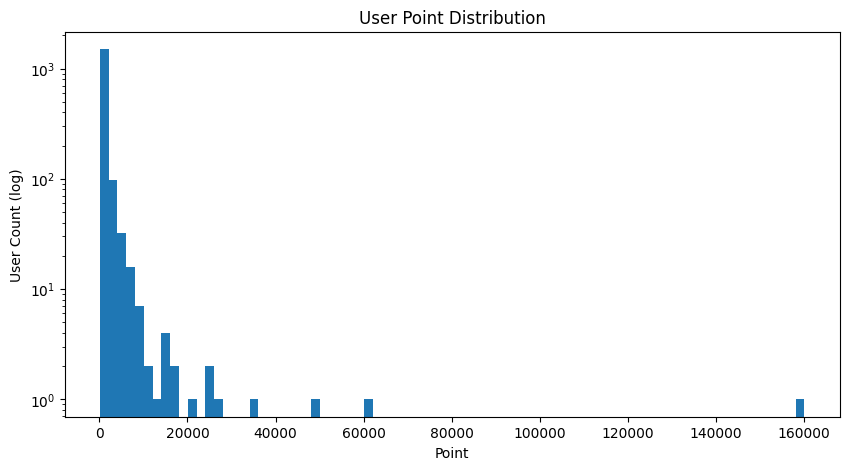

In [4]:
# ============================================================
# 3. 유저 포인트 분포 확인
# ============================================================

display(df_users["point"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.98, 0.99]).to_frame("point"))

plt.figure(figsize=(10, 5))
plt.hist(df_users["point"], bins=80)
plt.yscale("log")
plt.title("User Point Distribution")
plt.xlabel("Point")
plt.ylabel("User Count (log)")
plt.show()

In [5]:
# ============================================================
# 4. 기본 강화 파라미터
# ============================================================

MAX_LEVEL = {1: 50, 2: 80, 3: 100}

FAIL_RETURN_WEIGHTS_1 = {30: 18, 31: 16, 32: 14, 33: 12, 34: 10, 35: 9, 36: 7, 37: 6, 38: 5, 39: 3}
FAIL_RETURN_WEIGHTS_2 = {50: 18, 51: 16, 52: 14, 53: 12, 54: 10, 55: 9, 56: 7, 57: 6, 58: 5, 59: 3}


def base_cost(star: int, n: int) -> float:
    if star == 1:
        if n == 0:
            return 0
        if 1 <= n <= 10:
            return 2 * n
        if 11 <= n <= 20:
            return 20 + 2 * (n - 10)
        if 21 <= n <= 30:
            return 40 + 3 * (n - 20)
        if 31 <= n <= 40:
            return 70 + 5 * (n - 30)
        if 41 <= n <= 49:
            return 120 + 7 * (n - 40)

    if star == 2:
        if 0 <= n <= 40:
            return 15 + 3 * n
        if 41 <= n <= 60:
            return 135 + 6 * (n - 40)
        if 61 <= n <= 70:
            return 255 + 10 * (n - 60)
        if 71 <= n <= 79:
            return 355 + 15 * (n - 70)

    if star == 3:
        if 0 <= n <= 20:
            return 40 + 3 * n
        if 21 <= n <= 40:
            return 100 + 5 * (n - 20)
        if 41 <= n <= 60:
            return 200 + 7 * (n - 40)
        if 61 <= n <= 80:
            return 340 + 11 * (n - 60)
        if 81 <= n <= 90:
            return 560 + 16 * (n - 80)
        if 91 <= n <= 99:
            return 720 + 22 * (n - 90)

    raise ValueError(f"Invalid star/level for cost: star={star}, n={n}")


def current_probs(star: int, n: int) -> Tuple[float, float, float]:
    if star == 1:
        if 0 <= n <= 5:
            return 0.87, 0.11, 0.02
        if 6 <= n <= 15:
            return 0.82, 0.13, 0.05
        if 16 <= n <= 25:
            return 0.76, 0.16, 0.08
        if 26 <= n <= 35:
            return 0.70, 0.19, 0.11
        if 36 <= n <= 45:
            return 0.65, 0.21, 0.14
        if 46 <= n <= 49:
            return 0.60, 0.23, 0.17

    if star == 2:
        if 0 <= n <= 20:
            return 0.84, 0.13, 0.03
        if 21 <= n <= 40:
            return 0.77, 0.16, 0.07
        if 41 <= n <= 60:
            return 0.70, 0.20, 0.10
        if 61 <= n <= 70:
            return 0.63, 0.24, 0.13
        if 71 <= n <= 79:
            return 0.57, 0.27, 0.16

    if star == 3:
        if 0 <= n <= 20:
            return 0.82, 0.13, 0.05
        if 21 <= n <= 40:
            return 0.75, 0.16, 0.09
        if 41 <= n <= 60:
            return 0.68, 0.19, 0.13
        if 61 <= n <= 80:
            return 0.62, 0.23, 0.15
        if 81 <= n <= 90:
            return 0.57, 0.28, 0.15
        if 91 <= n <= 99:
            return 0.53, 0.32, 0.15

    raise ValueError(f"Invalid star/level for prob: star={star}, n={n}")


PROB_PRESETS = {
    "very_easy": (0.04, -0.02),
    "easy": (0.02, -0.01),
    "current": (0.00, 0.00),
    "mild_hard": (-0.03, 0.02),
    "hard": (-0.06, 0.04),
    "very_hard": (-0.09, 0.06),
}


def adjusted_probs(star: int, n: int, preset: str) -> Tuple[float, float, float]:
    ps, pk, pf = current_probs(star, n)
    ds, df = PROB_PRESETS[preset]

    ps2 = min(max(ps + ds, 0.05), 0.95)
    pf2 = min(max(pf + df, 0.00), 0.90)

    if ps2 + pf2 >= 0.98:
        ps2 = 0.98 - pf2

    pk2 = 1.0 - ps2 - pf2

    if pk2 < 0:
        total = ps2 + pf2
        ps2, pf2 = ps2 / total, pf2 / total
        pk2 = 0.0

    return ps2, pk2, pf2

print("기본 파라미터 정의 완료")

기본 파라미터 정의 완료


In [6]:
# ============================================================
# 5. CPU 정확 기대비용 계산
# ============================================================

def step_expectations(star: int, cost_multiplier: float, prob_preset: str) -> List[float]:
    max_level = MAX_LEVEL[star]
    T = [0.0 for _ in range(max_level)]

    for n in range(max_level):
        ps, _, pf = adjusted_probs(star, n, prob_preset)
        c = base_cost(star, n) * cost_multiplier
        prev = 0.0 if n == 0 else T[n - 1]
        T[n] = (c + pf * prev) / ps

    return T


def expected_cost_between(T: List[float], start_level: int, end_level: int) -> float:
    if end_level <= start_level:
        return 0.0
    return sum(T[start_level:end_level])


def weighted_return_recovery_cost(T: List[float], return_weights: Dict[int, int], target_level: int) -> float:
    total_w = sum(return_weights.values())
    return sum((w / total_w) * expected_cost_between(T, lvl, target_level) for lvl, w in return_weights.items())


def promotion_expectation(promo_cost: float, promo_success: float, recovery_cost: float) -> float:
    p = promo_success
    q = 1.0 - p
    return (promo_cost + q * recovery_cost) / p


@dataclass
class CostModel:
    T1: List[float]
    T2: List[float]
    T3: List[float]
    ex_1_50: float
    ex_2_entry: float
    ex_2_80: float
    ex_3_entry: float
    ex_3_100: float


def build_cost_model(
    cost_mul_1: float,
    cost_mul_2: float,
    cost_mul_3: float,
    prob_preset_1: str,
    prob_preset_2: str,
    prob_preset_3: str,
    promo12_cost: int,
    promo12_success: float,
    promo23_cost: int,
    promo23_success: float,
) -> CostModel:
    T1 = step_expectations(1, cost_mul_1, prob_preset_1)
    T2 = step_expectations(2, cost_mul_2, prob_preset_2)
    T3 = step_expectations(3, cost_mul_3, prob_preset_3)

    ex1 = expected_cost_between(T1, 0, 50)
    rec12 = weighted_return_recovery_cost(T1, FAIL_RETURN_WEIGHTS_1, 50)
    promo12 = promotion_expectation(promo12_cost, promo12_success, rec12)

    ex2_upgrade = expected_cost_between(T2, 0, 80)
    rec23 = weighted_return_recovery_cost(T2, FAIL_RETURN_WEIGHTS_2, 80)
    promo23 = promotion_expectation(promo23_cost, promo23_success, rec23)

    ex2_entry = ex1 + promo12
    ex2_80 = ex2_entry + ex2_upgrade
    ex3_entry = ex2_80 + promo23
    ex3_100 = ex3_entry + expected_cost_between(T3, 0, 100)

    return CostModel(T1, T2, T3, ex1, ex2_entry, ex2_80, ex3_entry, ex3_100)


current_model = build_cost_model(1.0, 1.0, 1.0, "current", "current", "current", 190, 0.55, 505, 0.55)

df_current_ex = pd.DataFrame([{
    "1성50강": current_model.ex_1_50,
    "2성진입": current_model.ex_2_entry,
    "2성80강": current_model.ex_2_80,
    "3성진입": current_model.ex_3_entry,
    "3성100강": current_model.ex_3_100,
}]).round(2)

display(df_current_ex)

assert current_model.ex_1_50 > 0
assert current_model.ex_3_100 > current_model.ex_3_entry

,1성50강,2성진입,2성80강,3성진입,3성100강
0,6153.97,10080.09,36217.77,52188.13,122388.06


In [7]:
# ============================================================
# 6. 상태 추정 + 보너스율
# ============================================================

def level_reachable(T: List[float], budget: float, max_level: int) -> int:
    spent = 0.0
    level = 0
    for n in range(max_level):
        if spent + T[n] <= budget:
            spent += T[n]
            level = n + 1
        else:
            break
    return level


def infer_state_from_budget(budget: float, model: CostModel) -> Tuple[int, int]:
    if budget < model.ex_1_50:
        return 1, level_reachable(model.T1, budget, 50)
    if budget < model.ex_2_entry:
        return 1, 50
    if budget < model.ex_2_80:
        return 2, level_reachable(model.T2, budget - model.ex_2_entry, 80)
    if budget < model.ex_3_entry:
        return 2, 80
    if budget < model.ex_3_100:
        return 3, level_reachable(model.T3, budget - model.ex_3_entry, 100)
    return 3, 100


BONUS_PROFILES = {
    "very_low": {1: (1.0, 0.08, 5.0), 2: (5.0, 0.12, 15.0), 3: (12.0, 0.18, 30.0)},
    "low": {1: (1.5, 0.10, 6.5), 2: (6.0, 0.15, 18.0), 3: (16.0, 0.22, 38.0)},
    "balanced": {1: (2.0, 0.12, 8.0), 2: (8.0, 0.175, 22.0), 3: (20.0, 0.25, 45.0)},
    "mid": {1: (3.0, 0.16, 11.0), 2: (10.0, 0.25, 30.0), 3: (24.0, 0.32, 56.0)},
    "high": {1: (4.0, 0.22, 15.0), 2: (12.0, 0.35, 40.0), 3: (28.0, 0.42, 70.0)},
    "current_like": {1: (5.0, 0.40, 25.0), 2: (15.0, 0.45, 50.0), 3: (30.0, 0.50, 80.0)},
}


def bonus_rate(star: int, level: int, profile_name: str) -> float:
    base, per, cap = BONUS_PROFILES[profile_name][star]
    return min(cap, base + per * level)


points_list = [u.point for u in users]
reach_summary = {
    "n_1_50": sum(p >= current_model.ex_1_50 for p in points_list),
    "n_2_entry": sum(p >= current_model.ex_2_entry for p in points_list),
    "n_2_80": sum(p >= current_model.ex_2_80 for p in points_list),
    "n_3_entry": sum(p >= current_model.ex_3_entry for p in points_list),
    "n_3_100": sum(p >= current_model.ex_3_100 for p in points_list),
}
display(pd.DataFrame([reach_summary]))

,n_1_50,n_2_entry,n_2_80,n_3_entry,n_3_100
0,40,18,3,2,1


In [8]:
# ============================================================
# 7. GPU/NumPy 배열 준비
# ============================================================

points_np = df_users["point"].to_numpy(dtype=np.float64)
total_correct_np = df_users["total_correct"].to_numpy(dtype=np.float64)
total_points = float(points_np.sum())
max_point = float(points_np.max())
points_x = xp.asarray(points_np)

preset_names = list(PROB_PRESETS.keys())
preset_to_id = {name: i for i, name in enumerate(preset_names)}
preset_delta_success = xp.asarray([PROB_PRESETS[name][0] for name in preset_names], dtype=xp.float64)
preset_delta_fail = xp.asarray([PROB_PRESETS[name][1] for name in preset_names], dtype=xp.float64)

bonus_names = list(BONUS_PROFILES.keys())
bonus_to_id = {name: i for i, name in enumerate(bonus_names)}

bonus_base = np.zeros((len(bonus_names), 4), dtype=np.float64)
bonus_per = np.zeros((len(bonus_names), 4), dtype=np.float64)
bonus_cap = np.zeros((len(bonus_names), 4), dtype=np.float64)

for pname, pid in bonus_to_id.items():
    for star in [1, 2, 3]:
        b, p, c = BONUS_PROFILES[pname][star]
        bonus_base[pid, star] = b
        bonus_per[pid, star] = p
        bonus_cap[pid, star] = c

bonus_base_x = xp.asarray(bonus_base)
bonus_per_x = xp.asarray(bonus_per)
bonus_cap_x = xp.asarray(bonus_cap)


def make_base_arrays(star: int):
    maxl = MAX_LEVEL[star]
    costs = np.array([base_cost(star, n) for n in range(maxl)], dtype=np.float64)
    ps = []
    pf = []
    for n in range(maxl):
        s, k, f = current_probs(star, n)
        ps.append(s)
        pf.append(f)
    return xp.asarray(costs), xp.asarray(np.array(ps)), xp.asarray(np.array(pf))


cost1_x, ps1_base_x, pf1_base_x = make_base_arrays(1)
cost2_x, ps2_base_x, pf2_base_x = make_base_arrays(2)
cost3_x, ps3_base_x, pf3_base_x = make_base_arrays(3)

print("USE_GPU:", USE_GPU)
print("users:", len(points_np), "total_points:", total_points)

USE_GPU: True
users: 1668 total_points: 1906336.0


In [9]:
# ============================================================
# 8. GPU/NumPy batch 기대비용 계산
# ============================================================

def adjusted_prob_arrays(ps_base, pf_base, preset_ids):
    ds = preset_delta_success[preset_ids][:, None]
    df = preset_delta_fail[preset_ids][:, None]

    ps = xp.clip(ps_base[None, :] + ds, 0.05, 0.95)
    pf = xp.clip(pf_base[None, :] + df, 0.00, 0.90)

    over = (ps + pf) >= 0.98
    ps = xp.where(over, 0.98 - pf, ps)

    pk = 1.0 - ps - pf
    neg = pk < 0
    total = ps + pf
    ps = xp.where(neg, ps / total, ps)
    pf = xp.where(neg, pf / total, pf)

    return ps, pf


def step_expectations_batch(star, cost_mul, preset_ids):
    if star == 1:
        costs, ps_base, pf_base, maxl = cost1_x, ps1_base_x, pf1_base_x, 50
    elif star == 2:
        costs, ps_base, pf_base, maxl = cost2_x, ps2_base_x, pf2_base_x, 80
    else:
        costs, ps_base, pf_base, maxl = cost3_x, ps3_base_x, pf3_base_x, 100

    ps, pf = adjusted_prob_arrays(ps_base, pf_base, preset_ids)
    T = xp.zeros((cost_mul.shape[0], maxl), dtype=xp.float64)

    for n in range(maxl):
        c = costs[n] * cost_mul
        prev = 0.0 if n == 0 else T[:, n - 1]
        T[:, n] = (c + pf[:, n] * prev) / ps[:, n]

    return T


def recovery_cost_batch(T, weights_dict, target_level):
    levels = list(weights_dict.keys())
    weights = xp.asarray([weights_dict[lvl] for lvl in levels], dtype=xp.float64)
    weights = weights / weights.sum()
    cs = xp.cumsum(T, axis=1)
    rec = xp.zeros((T.shape[0],), dtype=xp.float64)

    for lvl, w in zip(levels, weights):
        segment = cs[:, target_level - 1] if lvl == 0 else cs[:, target_level - 1] - cs[:, lvl - 1]
        rec += w * segment

    return rec


def build_cost_model_batch(batch):
    cost_mul_1 = xp.asarray(batch["cost_mul_1"], dtype=xp.float64)
    cost_mul_2 = xp.asarray(batch["cost_mul_2"], dtype=xp.float64)
    cost_mul_3 = xp.asarray(batch["cost_mul_3"], dtype=xp.float64)

    p1 = xp.asarray(batch["prob_preset_1"], dtype=xp.int64)
    p2 = xp.asarray(batch["prob_preset_2"], dtype=xp.int64)
    p3 = xp.asarray(batch["prob_preset_3"], dtype=xp.int64)

    promo12_cost = xp.asarray(batch["promo12_cost"], dtype=xp.float64)
    promo12_success = xp.asarray(batch["promo12_success"], dtype=xp.float64)
    promo23_cost = xp.asarray(batch["promo23_cost"], dtype=xp.float64)
    promo23_success = xp.asarray(batch["promo23_success"], dtype=xp.float64)

    T1 = step_expectations_batch(1, cost_mul_1, p1)
    T2 = step_expectations_batch(2, cost_mul_2, p2)
    T3 = step_expectations_batch(3, cost_mul_3, p3)

    ex1 = T1.sum(axis=1)
    rec12 = recovery_cost_batch(T1, FAIL_RETURN_WEIGHTS_1, 50)
    promo12 = (promo12_cost + (1 - promo12_success) * rec12) / promo12_success

    ex2_upgrade = T2.sum(axis=1)
    rec23 = recovery_cost_batch(T2, FAIL_RETURN_WEIGHTS_2, 80)
    promo23 = (promo23_cost + (1 - promo23_success) * rec23) / promo23_success

    ex2_entry = ex1 + promo12
    ex2_80 = ex2_entry + ex2_upgrade
    ex3_entry = ex2_80 + promo23
    ex3_100 = ex3_entry + T3.sum(axis=1)

    return ex1, ex2_entry, ex2_80, ex3_entry, ex3_100

In [10]:
# ============================================================
# 9. 탐색공간 설정
# ============================================================

def frange(start: float, stop: float, step: float):
    x = start
    while x <= stop + 1e-9:
        yield round(x, 10)
        x += step


def build_search_space(dense=False):
    if dense:
        return {
            "cost_mul_1": [round(x, 2) for x in frange(0.60, 1.05, 0.05)],
            "cost_mul_2": [round(x, 2) for x in frange(0.80, 1.80, 0.10)],
            "cost_mul_3": [round(x, 2) for x in frange(1.50, 4.00, 0.25)],
            "prob_preset_1": ["very_easy", "easy", "current", "mild_hard"],
            "prob_preset_2": ["easy", "current", "mild_hard", "hard"],
            "prob_preset_3": ["current", "mild_hard", "hard", "very_hard"],
            "promo12_cost": [300, 500, 750, 1000, 1500, 2000],
            "promo12_success": [0.55, 0.60, 0.65, 0.70],
            "promo23_cost": [3000, 5000, 7500, 10000, 12500, 15000, 20000],
            "promo23_success": [0.45, 0.50, 0.55, 0.60],
            "bonus_profile": ["very_low", "low", "balanced", "mid", "high", "current_like"],
        }

    return {
        "cost_mul_1": [0.65, 0.75, 0.85, 0.95],
        "cost_mul_2": [1.00, 1.20, 1.40, 1.60],
        "cost_mul_3": [2.00, 2.50, 3.00, 3.50],
        "prob_preset_1": ["easy", "current", "mild_hard"],
        "prob_preset_2": ["current", "mild_hard", "hard"],
        "prob_preset_3": ["current", "mild_hard", "hard"],
        "promo12_cost": [500, 750, 1000, 1500],
        "promo12_success": [0.55, 0.60, 0.65],
        "promo23_cost": [5000, 7500, 10000, 15000],
        "promo23_success": [0.50, 0.55, 0.60],
        "bonus_profile": ["low", "balanced", "mid", "high"],
    }


def count_space(space):
    total = 1
    for v in space.values():
        total *= len(v)
    return total


space_quick = build_search_space(dense=False)
space_dense = build_search_space(dense=True)

print("quick cases:", f"{count_space(space_quick):,}")
print("dense cases:", f"{count_space(space_dense):,}")

quick cases: 995,328
dense cases: 312,238,080


In [11]:
# ============================================================
# 10. GPU/NumPy 작은 sanity test
# ============================================================

test_batch = {
    "cost_mul_1": np.array([1.0, 0.75], dtype=np.float64),
    "cost_mul_2": np.array([1.0, 1.0], dtype=np.float64),
    "cost_mul_3": np.array([1.0, 2.0], dtype=np.float64),
    "prob_preset_1": np.array([preset_to_id["current"], preset_to_id["easy"]], dtype=np.int64),
    "prob_preset_2": np.array([preset_to_id["current"], preset_to_id["mild_hard"]], dtype=np.int64),
    "prob_preset_3": np.array([preset_to_id["current"], preset_to_id["current"]], dtype=np.int64),
    "promo12_cost": np.array([190, 1000], dtype=np.float64),
    "promo12_success": np.array([0.55, 0.65], dtype=np.float64),
    "promo23_cost": np.array([505, 7500], dtype=np.float64),
    "promo23_success": np.array([0.55, 0.55], dtype=np.float64),
}
test_batch_x = {k: xp.asarray(v) for k, v in test_batch.items()}
_test = build_cost_model_batch(test_batch_x)
_test_cpu = [cp.asnumpy(x) if USE_GPU else np.asarray(x) for x in _test]
print("batch sanity output:")
for name, arr in zip(["ex1", "ex2_entry", "ex2_80", "ex3_entry", "ex3_100"], _test_cpu):
    print(name, arr)

assert _test_cpu[0].shape[0] == 2
assert np.all(_test_cpu[4] > _test_cpu[3])
print("sanity test 통과")

batch sanity output:
ex1 [6153.96728703 4375.47649056]
ex2_entry [10080.08500604  7582.88471313]
ex2_80 [36217.77321844 36479.00381582]
ex3_entry [52188.13058926 66920.54117571]
ex3_100 [122388.06004558 207320.40008834]
sanity test 통과


In [12]:
# ============================================================
# 11. 1차 탐색 함수
# ============================================================

def iter_combinations_for_search(space):
    keys = [
        "cost_mul_1", "cost_mul_2", "cost_mul_3",
        "prob_preset_1", "prob_preset_2", "prob_preset_3",
        "promo12_cost", "promo12_success",
        "promo23_cost", "promo23_success",
        "bonus_profile",
    ]
    for vals in itertools.product(*(space[k] for k in keys)):
        yield dict(zip(keys, vals))


def chunked_iter(iterator, batch_size):
    batch = []
    for item in iterator:
        batch.append(item)
        if len(batch) >= batch_size:
            yield batch
            batch = []
    if batch:
        yield batch


def batch_to_arrays(batch):
    return {
        "cost_mul_1": np.array([b["cost_mul_1"] for b in batch], dtype=np.float64),
        "cost_mul_2": np.array([b["cost_mul_2"] for b in batch], dtype=np.float64),
        "cost_mul_3": np.array([b["cost_mul_3"] for b in batch], dtype=np.float64),
        "prob_preset_1": np.array([preset_to_id[b["prob_preset_1"]] for b in batch], dtype=np.int64),
        "prob_preset_2": np.array([preset_to_id[b["prob_preset_2"]] for b in batch], dtype=np.int64),
        "prob_preset_3": np.array([preset_to_id[b["prob_preset_3"]] for b in batch], dtype=np.int64),
        "promo12_cost": np.array([b["promo12_cost"] for b in batch], dtype=np.float64),
        "promo12_success": np.array([b["promo12_success"] for b in batch], dtype=np.float64),
        "promo23_cost": np.array([b["promo23_cost"] for b in batch], dtype=np.float64),
        "promo23_success": np.array([b["promo23_success"] for b in batch], dtype=np.float64),
        "bonus_profile": np.array([bonus_to_id[b["bonus_profile"]] for b in batch], dtype=np.int64),
    }


def to_cpu(a):
    if USE_GPU:
        return cp.asnumpy(a)
    return np.asarray(a)


def rough_issue_rate_fast(ex1, ex2_entry, ex2_80, ex3_entry, ex3_100, bonus_profile_ids):
    pts = points_x[:, None]

    ex1b = ex1[None, :]
    ex2eb = ex2_entry[None, :]
    ex2b = ex2_80[None, :]
    ex3eb = ex3_entry[None, :]
    ex3b = ex3_100[None, :]

    B = ex1.shape[0]
    star = xp.ones((len(points_np), B), dtype=xp.int8)
    level = xp.floor(xp.clip((pts / xp.maximum(ex1b, 1e-9)) * 50, 0, 50))

    mask2 = pts >= ex2eb
    star = xp.where(mask2, 2, star)
    level2 = xp.floor(xp.clip(((pts - ex2eb) / xp.maximum(ex2b - ex2eb, 1e-9)) * 80, 0, 80))
    level = xp.where(mask2, level2, level)

    mask2max = (pts >= ex2b) & (pts < ex3eb)
    star = xp.where(mask2max, 2, star)
    level = xp.where(mask2max, 80, level)

    mask3 = pts >= ex3eb
    star = xp.where(mask3, 3, star)
    level3 = xp.floor(xp.clip(((pts - ex3eb) / xp.maximum(ex3b - ex3eb, 1e-9)) * 100, 0, 100))
    level = xp.where(mask3, level3, level)

    mask3max = pts >= ex3b
    star = xp.where(mask3max, 3, star)
    level = xp.where(mask3max, 100, level)

    pid = bonus_profile_ids[None, :]
    pid_matrix = xp.repeat(pid, len(points_np), axis=0)

    base = xp.take_along_axis(bonus_base_x[pid_matrix], star[..., None], axis=2).squeeze(-1)
    per = xp.take_along_axis(bonus_per_x[pid_matrix], star[..., None], axis=2).squeeze(-1)
    cap = xp.take_along_axis(bonus_cap_x[pid_matrix], star[..., None], axis=2).squeeze(-1)

    rates = xp.minimum(cap, base + per * level)
    issue_amount = (points_x[:, None] * (rates / 100.0)).sum(axis=0)
    issue_rate = issue_amount / total_points
    avg_bonus = rates.mean(axis=0)
    max_bonus = rates.max(axis=0)

    return issue_rate, avg_bonus, max_bonus


def wide_search_first_pass(space, top_k=1000, batch_size=5000, max_batches=None, progress_every=10):
    iterator = iter_combinations_for_search(space)
    total_cases = count_space(space)

    heap = []
    checked = 0
    batch_count = 0
    start = time.time()

    for batch in chunked_iter(iterator, batch_size):
        if max_batches is not None and batch_count >= max_batches:
            break

        arr = batch_to_arrays(batch)
        arr_x = {k: xp.asarray(v) for k, v in arr.items()}

        ex1, ex2_entry, ex2_80, ex3_entry, ex3_100 = build_cost_model_batch(arr_x)

        pts = points_x[:, None]
        n1 = (pts >= ex1[None, :]).sum(axis=0)
        n2e = (pts >= ex2_entry[None, :]).sum(axis=0)
        n2 = (pts >= ex2_80[None, :]).sum(axis=0)
        n3e = (pts >= ex3_entry[None, :]).sum(axis=0)
        n3 = (pts >= ex3_100[None, :]).sum(axis=0)

        issue_rate, avg_bonus, max_bonus = rough_issue_rate_fast(
            ex1, ex2_entry, ex2_80, ex3_entry, ex3_100, arr_x["bonus_profile"]
        )

        score = (
            0.50 * xp.abs(n1 - 65)
            + 1.20 * xp.abs(n2e - 24)
            + 4.00 * xp.abs(n2 - 3)
            + 1.50 * xp.abs(n3e - 1)
            + 10.00 * xp.maximum(0, n3e - 1)
            + 120.0 * n3
            + 500.0 * xp.abs(issue_rate - 0.12)
            + 4.0 * xp.abs(avg_bonus - 5.0)
            + xp.where(max_bonus > 50, 3.0 * (max_bonus - 50), 0)
            + xp.where(ex3_100 <= max_point, 150.0 + (max_point - ex3_100) / 1000.0, 0)
        )

        score_cpu = to_cpu(score)
        local_k = min(top_k, len(batch))
        idx = np.argpartition(score_cpu, local_k - 1)[:local_k]

        ex1_cpu = to_cpu(ex1)
        ex2e_cpu = to_cpu(ex2_entry)
        ex2_cpu = to_cpu(ex2_80)
        ex3e_cpu = to_cpu(ex3_entry)
        ex3_cpu = to_cpu(ex3_100)
        n1_cpu = to_cpu(n1)
        n2e_cpu = to_cpu(n2e)
        n2_cpu = to_cpu(n2)
        n3e_cpu = to_cpu(n3e)
        n3_cpu = to_cpu(n3)
        issue_cpu = to_cpu(issue_rate)
        avg_bonus_cpu = to_cpu(avg_bonus)
        max_bonus_cpu = to_cpu(max_bonus)

        for i in idx:
            i = int(i)
            b = batch[i].copy()
            row = {
                **b,
                "rough_score": float(score_cpu[i]),
                "ex_1_50": float(ex1_cpu[i]),
                "ex_2_entry": float(ex2e_cpu[i]),
                "ex_2_80": float(ex2_cpu[i]),
                "ex_3_entry": float(ex3e_cpu[i]),
                "ex_3_100": float(ex3_cpu[i]),
                "n_1_50": int(n1_cpu[i]),
                "n_2_entry": int(n2e_cpu[i]),
                "n_2_80": int(n2_cpu[i]),
                "n_3_entry": int(n3e_cpu[i]),
                "n_3_100": int(n3_cpu[i]),
                "rough_issue_rate_by_point": float(issue_cpu[i]),
                "rough_avg_bonus_rate": float(avg_bonus_cpu[i]),
                "rough_max_bonus_rate": float(max_bonus_cpu[i]),
            }
            item = (-row["rough_score"], checked + i, row)
            if len(heap) < top_k:
                heapq.heappush(heap, item)
            else:
                if item[0] > heap[0][0]:
                    heapq.heapreplace(heap, item)

        checked += len(batch)
        batch_count += 1

        if progress_every and batch_count % progress_every == 0:
            elapsed = time.time() - start
            print(f"[progress] batch={batch_count:,}, checked={checked:,}/{total_cases:,}, elapsed={elapsed:.1f}s")

    rows = [x[2] for x in heap]
    rows.sort(key=lambda r: r["rough_score"])
    return pd.DataFrame(rows)


print("1차 탐색 함수 정의 완료")

1차 탐색 함수 정의 완료


In [18]:
# ============================================================
# 12. 1차 탐색 실행
# ============================================================

RUN_SMALL_TEST = False
RUN_QUICK_FULL = False
RUN_DENSE_FULL = True

DEFAULT_BATCH_SIZE = 10000

if RUN_SMALL_TEST:
    print("small test 실행")
    df_first_pass = wide_search_first_pass(
        space_quick,
        top_k=100,
        batch_size=1000,
        max_batches=2,
        progress_every=1,
    )
    display(df_first_pass.head(10))

if RUN_QUICK_FULL:
    print("quick full 실행")
    df_first_pass = wide_search_first_pass(
        space_quick,
        top_k=1000,
        batch_size=DEFAULT_BATCH_SIZE,
        max_batches=None,
        progress_every=20,
    )
    display(df_first_pass.head(20))

if RUN_DENSE_FULL:
    print("dense full 실행")
    df_first_pass = wide_search_first_pass(
        space_dense,
        top_k=3000,
        batch_size=DEFAULT_BATCH_SIZE,
        max_batches=None,
        progress_every=20,
    )
    display(df_first_pass.head(20))

dense full 실행
[progress] batch=20, checked=200,000/312,238,080, elapsed=1.5s
[progress] batch=40, checked=400,000/312,238,080, elapsed=2.9s
[progress] batch=60, checked=600,000/312,238,080, elapsed=4.5s
[progress] batch=80, checked=800,000/312,238,080, elapsed=6.0s
[progress] batch=100, checked=1,000,000/312,238,080, elapsed=7.4s
[progress] batch=120, checked=1,200,000/312,238,080, elapsed=8.9s
[progress] batch=140, checked=1,400,000/312,238,080, elapsed=10.4s
[progress] batch=160, checked=1,600,000/312,238,080, elapsed=11.9s
[progress] batch=180, checked=1,800,000/312,238,080, elapsed=13.4s
[progress] batch=200, checked=2,000,000/312,238,080, elapsed=14.8s
[progress] batch=220, checked=2,200,000/312,238,080, elapsed=16.3s
[progress] batch=240, checked=2,400,000/312,238,080, elapsed=17.8s
[progress] batch=260, checked=2,600,000/312,238,080, elapsed=19.2s
[progress] batch=280, checked=2,800,000/312,238,080, elapsed=20.7s
[progress] batch=300, checked=3,000,000/312,238,080, elapsed=22.2s

,cost_mul_1,cost_mul_2,cost_mul_3,prob_preset_1,prob_preset_2,prob_preset_3,promo12_cost,promo12_success,promo23_cost,promo23_success,bonus_profile,rough_score,ex_1_50,ex_2_entry,ex_2_80,ex_3_entry,ex_3_100,n_1_50,n_2_entry,n_2_80,n_3_entry,n_3_100,rough_issue_rate_by_point,rough_avg_bonus_rate,rough_max_bonus_rate
0,0.65,0.9,2.75,mild_hard,hard,mild_hard,300,0.55,20000,0.45,mid,2.505861,4401.136199,7526.213359,36625.331904,106647.446199,323093.470666,66,24,3,1,0,0.120002,4.498747,31.68
1,0.65,0.9,4.00,mild_hard,hard,hard,300,0.55,10000,0.55,mid,2.505861,4401.136199,7526.213359,36625.331904,71929.391887,430466.398695,66,24,3,1,0,0.120002,4.498747,31.68
2,0.65,0.9,2.75,mild_hard,hard,very_hard,300,0.55,12500,0.45,mid,2.505861,4401.136199,7526.213359,36625.331904,89980.779533,376573.291402,66,24,3,1,0,0.120002,4.498747,31.68
3,0.65,0.9,2.50,mild_hard,hard,very_hard,300,0.55,15000,0.45,mid,2.505861,4401.136199,7526.213359,36625.331904,95536.335088,356074.982242,66,24,3,1,0,0.120002,4.498747,31.68
4,0.65,0.9,3.25,mild_hard,hard,very_hard,300,0.55,15000,0.60,mid,2.505861,4401.136199,7526.213359,36625.331904,75576.788186,414277.029486,66,24,3,1,0,0.120002,4.498747,31.68
5,0.65,0.9,3.75,mild_hard,hard,hard,300,0.55,12500,0.55,mid,2.505861,4401.136199,7526.213359,36625.331904,76474.846432,412603.290315,66,24,3,1,0,0.120002,4.498747,31.68
6,0.65,0.9,3.75,mild_hard,hard,hard,300,0.55,7500,0.45,mid,2.505861,4401.136199,7526.213359,36625.331904,78869.668422,414998.112304,66,24,3,1,0,0.120002,4.498747,31.68
7,0.65,0.9,4.00,mild_hard,hard,hard,300,0.55,7500,0.50,mid,2.505861,4401.136199,7526.213359,36625.331904,72552.516328,431089.523136,66,24,3,1,0,0.120002,4.498747,31.68
8,0.65,0.9,4.00,mild_hard,hard,mild_hard,300,0.55,10000,0.45,mid,2.505861,4401.136199,7526.213359,36625.331904,84425.223977,399255.805020,66,24,3,1,0,0.120002,4.498747,31.68
9,0.65,0.9,3.50,mild_hard,hard,very_hard,300,0.55,12500,0.60,mid,2.505861,4401.136199,7526.213359,36625.331904,71410.121520,436164.227535,66,24,3,1,0,0.120002,4.498747,31.68


In [19]:
# ============================================================
# 13. CPU 정확 평가 함수
# ============================================================

def percentile(values, q):
    values = sorted(values)
    idx = int(round((len(values) - 1) * q))
    return values[idx]


def evaluate_exact_row(row):
    model = build_cost_model(
        cost_mul_1=float(row["cost_mul_1"]),
        cost_mul_2=float(row["cost_mul_2"]),
        cost_mul_3=float(row["cost_mul_3"]),
        prob_preset_1=row["prob_preset_1"],
        prob_preset_2=row["prob_preset_2"],
        prob_preset_3=row["prob_preset_3"],
        promo12_cost=int(row["promo12_cost"]),
        promo12_success=float(row["promo12_success"]),
        promo23_cost=int(row["promo23_cost"]),
        promo23_success=float(row["promo23_success"]),
    )

    points = [u.point for u in users]
    states = [infer_state_from_budget(u.point, model) for u in users]
    rates = [bonus_rate(star, level, row["bonus_profile"]) for star, level in states]

    n_1_50 = sum(p >= model.ex_1_50 for p in points)
    n_2_entry = sum(p >= model.ex_2_entry for p in points)
    n_2_80 = sum(p >= model.ex_2_80 for p in points)
    n_3_entry = sum(p >= model.ex_3_entry for p in points)
    n_3_100 = sum(p >= model.ex_3_100 for p in points)

    issue_amount_by_point = sum(u.point * (r / 100.0) for u, r in zip(users, rates))
    issue_rate_by_point = issue_amount_by_point / sum(points)

    avg_bonus_rate = sum(rates) / len(rates)
    median_bonus_rate = percentile(rates, 0.5)
    p95_bonus_rate = percentile(rates, 0.95)
    max_bonus_rate = max(rates)

    score = (
        0.50 * abs(n_1_50 - 65)
        + 1.20 * abs(n_2_entry - 24)
        + 4.00 * abs(n_2_80 - 3)
        + 1.50 * abs(n_3_entry - 1)
        + 10.00 * max(0, n_3_entry - 1)
        + 120.0 * n_3_100
        + 500.0 * abs(issue_rate_by_point - 0.12)
        + 4.0 * abs(avg_bonus_rate - 5.0)
        + (3.0 * (max_bonus_rate - 50) if max_bonus_rate > 50 else 0)
        + (150.0 + (max(points) - model.ex_3_100) / 1000.0 if model.ex_3_100 <= max(points) else 0)
    )

    return {
        "score": score,
        "cost_mul_1": float(row["cost_mul_1"]),
        "cost_mul_2": float(row["cost_mul_2"]),
        "cost_mul_3": float(row["cost_mul_3"]),
        "prob_preset_1": row["prob_preset_1"],
        "prob_preset_2": row["prob_preset_2"],
        "prob_preset_3": row["prob_preset_3"],
        "promo12_cost": int(row["promo12_cost"]),
        "promo12_success": float(row["promo12_success"]),
        "promo23_cost": int(row["promo23_cost"]),
        "promo23_success": float(row["promo23_success"]),
        "bonus_profile": row["bonus_profile"],
        "ex_1_50": model.ex_1_50,
        "ex_2_entry": model.ex_2_entry,
        "ex_2_80": model.ex_2_80,
        "ex_3_entry": model.ex_3_entry,
        "ex_3_100": model.ex_3_100,
        "n_1_50": n_1_50,
        "n_2_entry": n_2_entry,
        "n_2_80": n_2_80,
        "n_3_entry": n_3_entry,
        "n_3_100": n_3_100,
        "avg_bonus_rate": avg_bonus_rate,
        "median_bonus_rate": median_bonus_rate,
        "p95_bonus_rate": p95_bonus_rate,
        "max_bonus_rate": max_bonus_rate,
        "issue_rate_by_point": issue_rate_by_point,
        "issue_amount_by_point": issue_amount_by_point,
    }


def exact_verify_top(df_candidates, top_n=200):
    rows = []
    top_n = min(top_n, len(df_candidates))
    for _, row in df_candidates.head(top_n).iterrows():
        rows.append(evaluate_exact_row(row))
    return pd.DataFrame(rows).sort_values("score").reset_index(drop=True)


assert "df_first_pass" in globals(), "먼저 1차 탐색 셀을 실행하세요."

df_exact = exact_verify_top(df_first_pass, top_n=200)
display(df_exact.head(30))

assert len(df_exact) > 0
assert df_exact["ex_3_100"].iloc[0] > df_exact["ex_3_entry"].iloc[0]
print("CPU 정확 재검증 완료")

,score,cost_mul_1,cost_mul_2,cost_mul_3,prob_preset_1,prob_preset_2,prob_preset_3,promo12_cost,promo12_success,promo23_cost,promo23_success,bonus_profile,ex_1_50,ex_2_entry,ex_2_80,ex_3_entry,ex_3_100,n_1_50,n_2_entry,n_2_80,n_3_entry,n_3_100,avg_bonus_rate,median_bonus_rate,p95_bonus_rate,max_bonus_rate,issue_rate_by_point,issue_amount_by_point
0,24.423675,0.65,1.1,4.00,mild_hard,current,current,500,0.55,12500,0.45,mid,4401.136199,7889.849723,36641.306756,89152.968066,369952.685891,66,24,3,1,0,6.908603,6.2,10.68,43.84,0.152579,290865.9350
1,24.423675,0.65,1.1,4.00,mild_hard,current,current,500,0.55,20000,0.55,mid,4401.136199,7889.849723,36641.306756,89562.336228,370362.054053,66,24,3,1,0,6.908603,6.2,10.68,43.84,0.152579,290865.9350
2,24.447369,0.65,1.2,3.75,mild_hard,easy,current,750,0.60,20000,0.55,mid,4401.136199,7753.050922,37421.444043,90781.829660,354031.565121,66,24,3,1,0,6.907896,6.2,10.68,44.16,0.152632,290967.0620
3,24.447369,0.65,1.2,3.75,mild_hard,easy,current,750,0.60,12500,0.45,mid,4401.136199,7753.050922,37421.444043,90589.427495,353839.162956,66,24,3,1,0,6.907896,6.2,10.68,44.16,0.152632,290967.0620
4,24.447369,0.65,1.2,3.50,mild_hard,easy,current,750,0.60,15000,0.45,mid,4401.136199,7753.050922,37421.444043,96144.983051,341844.736148,66,24,3,1,0,6.907896,6.2,10.68,44.16,0.152632,290967.0620
5,24.471824,0.65,1.1,3.75,mild_hard,current,current,1000,0.65,20000,0.50,mid,4401.136199,7637.298091,36388.755124,96625.568923,359875.304384,66,24,3,1,0,6.912008,6.2,10.68,43.52,0.152648,290997.5805
6,24.489910,0.65,1.2,3.50,mild_hard,easy,current,300,0.55,20000,0.50,mid,4401.136199,7526.213359,37194.606480,97968.411123,343668.164220,66,24,3,1,0,6.911151,6.2,10.68,43.84,0.152691,291079.6075
7,24.489910,0.65,1.2,3.00,mild_hard,easy,current,300,0.55,20000,0.45,mid,4401.136199,7526.213359,37194.606480,107029.256599,317629.044968,66,24,3,1,0,6.911151,6.2,10.68,43.84,0.152691,291079.6075
8,24.558782,0.65,1.1,3.25,mild_hard,current,mild_hard,500,0.55,15000,0.45,mid,4401.136199,7889.849723,36641.306756,94708.523621,350508.370718,66,24,3,1,0,6.908795,6.2,10.68,44.16,0.152847,291378.1270
9,24.558782,0.65,1.1,3.50,mild_hard,current,current,500,0.55,20000,0.50,mid,4401.136199,7889.849723,36641.306756,96878.120555,342577.873652,66,24,3,1,0,6.908795,6.2,10.68,44.16,0.152847,291378.1270


CPU 정확 재검증 완료


In [20]:
# ============================================================
# 14. 결과 저장/다운로드
# ============================================================

output_name = "artifact_search_exact_top.csv"
df_exact.to_csv(output_name, index=False, encoding="utf-8-sig")
print("저장 완료:", output_name)

display(df_exact.head(20))

try:
    from google.colab import files
    files.download(output_name)
except Exception:
    print("Colab이 아니므로 자동 다운로드를 생략합니다. 저장 경로:", Path(output_name).resolve())

저장 완료: artifact_search_exact_top.csv


,score,cost_mul_1,cost_mul_2,cost_mul_3,prob_preset_1,prob_preset_2,prob_preset_3,promo12_cost,promo12_success,promo23_cost,promo23_success,bonus_profile,ex_1_50,ex_2_entry,ex_2_80,ex_3_entry,ex_3_100,n_1_50,n_2_entry,n_2_80,n_3_entry,n_3_100,avg_bonus_rate,median_bonus_rate,p95_bonus_rate,max_bonus_rate,issue_rate_by_point,issue_amount_by_point
0,24.423675,0.65,1.1,4.00,mild_hard,current,current,500,0.55,12500,0.45,mid,4401.136199,7889.849723,36641.306756,89152.968066,369952.685891,66,24,3,1,0,6.908603,6.2,10.68,43.84,0.152579,290865.9350
1,24.423675,0.65,1.1,4.00,mild_hard,current,current,500,0.55,20000,0.55,mid,4401.136199,7889.849723,36641.306756,89562.336228,370362.054053,66,24,3,1,0,6.908603,6.2,10.68,43.84,0.152579,290865.9350
2,24.447369,0.65,1.2,3.75,mild_hard,easy,current,750,0.60,20000,0.55,mid,4401.136199,7753.050922,37421.444043,90781.829660,354031.565121,66,24,3,1,0,6.907896,6.2,10.68,44.16,0.152632,290967.0620
3,24.447369,0.65,1.2,3.75,mild_hard,easy,current,750,0.60,12500,0.45,mid,4401.136199,7753.050922,37421.444043,90589.427495,353839.162956,66,24,3,1,0,6.907896,6.2,10.68,44.16,0.152632,290967.0620
4,24.447369,0.65,1.2,3.50,mild_hard,easy,current,750,0.60,15000,0.45,mid,4401.136199,7753.050922,37421.444043,96144.983051,341844.736148,66,24,3,1,0,6.907896,6.2,10.68,44.16,0.152632,290967.0620
5,24.471824,0.65,1.1,3.75,mild_hard,current,current,1000,0.65,20000,0.50,mid,4401.136199,7637.298091,36388.755124,96625.568923,359875.304384,66,24,3,1,0,6.912008,6.2,10.68,43.52,0.152648,290997.5805
6,24.489910,0.65,1.2,3.50,mild_hard,easy,current,300,0.55,20000,0.50,mid,4401.136199,7526.213359,37194.606480,97968.411123,343668.164220,66,24,3,1,0,6.911151,6.2,10.68,43.84,0.152691,291079.6075
7,24.489910,0.65,1.2,3.00,mild_hard,easy,current,300,0.55,20000,0.45,mid,4401.136199,7526.213359,37194.606480,107029.256599,317629.044968,66,24,3,1,0,6.911151,6.2,10.68,43.84,0.152691,291079.6075
8,24.558782,0.65,1.1,3.25,mild_hard,current,mild_hard,500,0.55,15000,0.45,mid,4401.136199,7889.849723,36641.306756,94708.523621,350508.370718,66,24,3,1,0,6.908795,6.2,10.68,44.16,0.152847,291378.1270
9,24.558782,0.65,1.1,3.50,mild_hard,current,current,500,0.55,20000,0.50,mid,4401.136199,7889.849723,36641.306756,96878.120555,342577.873652,66,24,3,1,0,6.908795,6.2,10.68,44.16,0.152847,291378.1270


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
# ============================================================
# 15. 최상위 후보 요약
# ============================================================

best = df_exact.iloc[0]

print("=== BEST EXACT CANDIDATE ===")
print(f"score: {best['score']:.4f}")
print()
print("[파라미터]")
print(f"일반강화 비용 배율: 1성 x{best['cost_mul_1']}, 2성 x{best['cost_mul_2']}, 3성 x{best['cost_mul_3']}")
print(f"확률 프리셋: 1성 {best['prob_preset_1']}, 2성 {best['prob_preset_2']}, 3성 {best['prob_preset_3']}")
print(f"성급강화 1→2: 비용 {best['promo12_cost']}P, 성공률 {best['promo12_success']*100:.1f}%")
print(f"성급강화 2→3: 비용 {best['promo23_cost']}P, 성공률 {best['promo23_success']*100:.1f}%")
print(f"보너스 프로필: {best['bonus_profile']}")
print()
print("[기대비용]")
for col in ["ex_1_50", "ex_2_entry", "ex_2_80", "ex_3_entry", "ex_3_100"]:
    print(f"{col}: {best[col]:,.0f}P")

print()
print("[도달 가능 인원]")
for col in ["n_1_50", "n_2_entry", "n_2_80", "n_3_entry", "n_3_100"]:
    print(f"{col}: {int(best[col])}명")

print()
print("[경제 지표]")
print(f"평균 보너스율: {best['avg_bonus_rate']:.2f}%")
print(f"중앙값 보너스율: {best['median_bonus_rate']:.2f}%")
print(f"상위 5% 보너스율: {best['p95_bonus_rate']:.2f}%")
print(f"최대 보너스율: {best['max_bonus_rate']:.2f}%")
print(f"현재 점수 반복 기준 추가 발행률: {best['issue_rate_by_point']*100:.2f}%")

=== BEST EXACT CANDIDATE ===
score: 24.4237

[파라미터]
일반강화 비용 배율: 1성 x0.65, 2성 x1.1, 3성 x4.0
확률 프리셋: 1성 mild_hard, 2성 current, 3성 current
성급강화 1→2: 비용 500P, 성공률 55.0%
성급강화 2→3: 비용 12500P, 성공률 45.0%
보너스 프로필: mid

[기대비용]
ex_1_50: 4,401P
ex_2_entry: 7,890P
ex_2_80: 36,641P
ex_3_entry: 89,153P
ex_3_100: 369,953P

[도달 가능 인원]
n_1_50: 66명
n_2_entry: 24명
n_2_80: 3명
n_3_entry: 1명
n_3_100: 0명

[경제 지표]
평균 보너스율: 6.91%
중앙값 보너스율: 6.20%
상위 5% 보너스율: 10.68%
최대 보너스율: 43.84%
현재 점수 반복 기준 추가 발행률: 15.26%


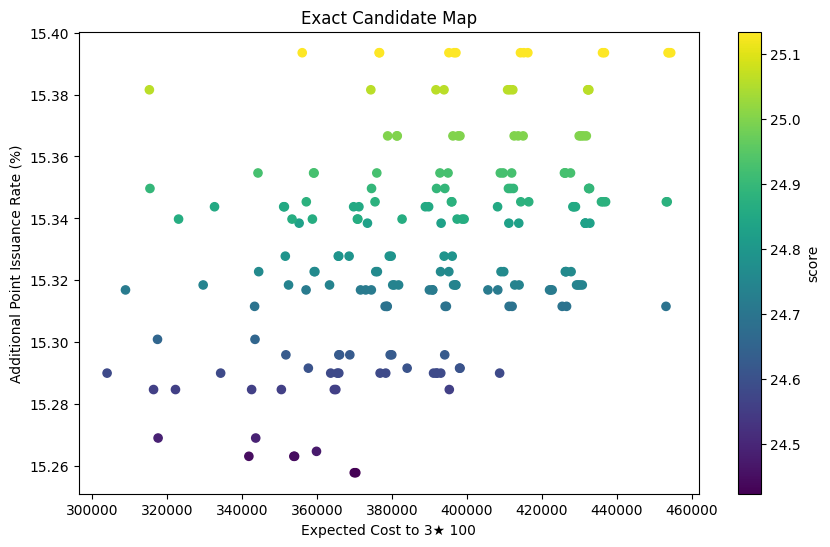

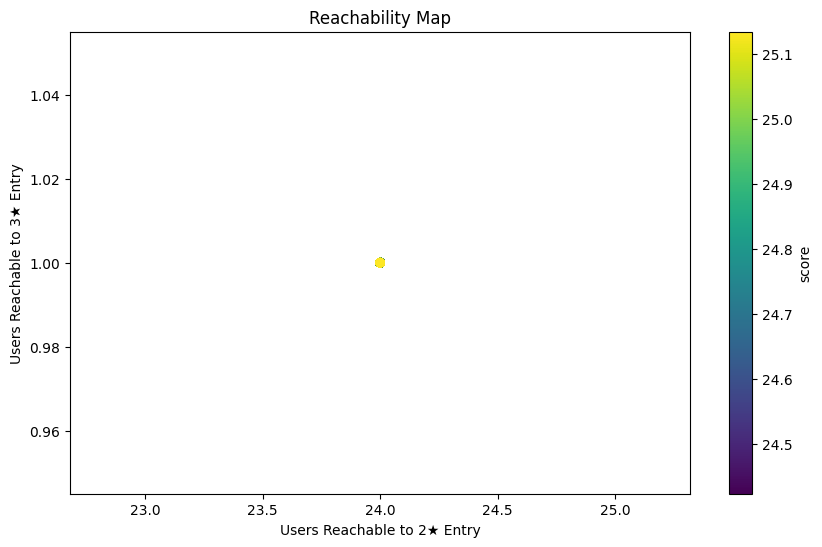

In [22]:
# ============================================================
# 16. 후보 시각화
# ============================================================

plt.figure(figsize=(10, 6))
plt.scatter(
    df_exact["ex_3_100"],
    df_exact["issue_rate_by_point"] * 100,
    c=df_exact["score"],
    s=35,
)
plt.colorbar(label="score")
plt.title("Exact Candidate Map")
plt.xlabel("Expected Cost to 3★ 100")
plt.ylabel("Additional Point Issuance Rate (%)")
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(
    df_exact["n_2_entry"],
    df_exact["n_3_entry"],
    c=df_exact["score"],
    s=35,
)
plt.colorbar(label="score")
plt.title("Reachability Map")
plt.xlabel("Users Reachable to 2★ Entry")
plt.ylabel("Users Reachable to 3★ Entry")
plt.show()

## 더 많이 돌리는 법

처음에는 기본값 그대로 실행하세요.

```python
RUN_SMALL_TEST = True
RUN_QUICK_FULL = False
RUN_DENSE_FULL = False
```

오류가 없으면 12번 셀에서 다음처럼 바꿉니다.

```python
RUN_SMALL_TEST = False
RUN_QUICK_FULL = True
RUN_DENSE_FULL = False
```

정말 많이 돌리려면:

```python
RUN_SMALL_TEST = False
RUN_QUICK_FULL = False
RUN_DENSE_FULL = True
```

GPU 메모리가 부족하면:

```python
DEFAULT_BATCH_SIZE = 2000
```

처럼 낮추세요.